# Forgewright CNC Tool-Wear -- Exploratory Data Analysis

This notebook does the exploratory data analysis of the sensor and log files provided so as to guide the wear analysis for CNC machines . On a high level, I do the following 3 steps: 
(1) profiles each raw csv on its own,
(2) establishes how the three files can be joined, 
(3) builds the joined reading-level table

Based on these 3 steps , I decide on required the feature engineering and candidate model architectures for wear detection.

In [1]:
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

sys.path.insert(0, "/data")
warnings.filterwarnings("ignore")

pd.set_option("display.width", 190)
pd.set_option("display.max_columns", 60)
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
    "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False,
})

RAW = "/data/raw"
power_raw = pd.read_csv(f"{RAW}/power.csv")
vib_raw = pd.read_csv(f"{RAW}/vibration.csv")
log_raw = pd.read_csv(f"{RAW}/production_log.csv")

print("power.csv         ", power_raw.shape)
print("vibration.csv     ", vib_raw.shape)
print("production_log.csv", log_raw.shape)

power.csv          (86405, 3)
vibration.csv      (168969, 4)
production_log.csv (94, 7)


## 1. Profiling each file on its own

### 1.1 Shape, dtypes, nulls, duplicates

In [2]:
def profile(df, name):
    print("=" * 78)
    print(f"{name}: {len(df):,} rows x {df.shape[1]} columns")
    print("-" * 78)
    info = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "nulls": df.isna().sum(),
        "null_%": (100 * df.isna().mean()).round(2),
        "n_unique": df.nunique(),
    })
    print(info.to_string())
    print(f"exact duplicate rows: {df.duplicated().sum()}")
    return info

_ = profile(power_raw, "power.csv")
_ = profile(vib_raw, "vibration.csv")
_ = profile(log_raw, "production_log.csv")

power.csv: 86,405 rows x 3 columns
------------------------------------------------------------------------------
              dtype  nulls  null_%  n_unique
timestamp       str      0    0.00     28800
machine_id      str      0    0.00         3
power_kw    float64     16    0.02     12722
exact duplicate rows: 5
vibration.csv: 168,969 rows x 4 columns
------------------------------------------------------------------------------
                    dtype  nulls  null_%  n_unique
timestamp             str      0     0.0    168632
machine_id            str      0     0.0         3
vibration_rms_g   float64      0     0.0      8236
vibration_peak_g  float64      0     0.0     23532
exact duplicate rows: 8
production_log.csv: 94 rows x 7 columns
------------------------------------------------------------------------------
              dtype  nulls  null_%  n_unique
job_id          str      0    0.00        94
machine_id      str      0    0.00         3
part_type       str      0    

**Read-out**

* No nulls in either sensor file; `production_log.quantity` has 3 nulls.
* A handful of exact duplicate rows exists in both sensor files (re-sent telemetry packets).
* `quantity` arrives as float only because of those nulls -- it is conceptually an integer.

### 1.2 Categorical columns -- unique classes

In [3]:
for df, name, cols in [
    (power_raw, "power", ["machine_id"]),
    (vib_raw, "vibration", ["machine_id"]),
    (log_raw, "production_log", ["machine_id", "part_type", "operator"]),
]:
    for c in cols:
        vc = df[c].value_counts()
        print(f"{name}.{c}: {df[c].nunique()} classes")
        print(vc.to_string(), "\n")

print("machine sets identical across all three files:",
      set(power_raw.machine_id) == set(vib_raw.machine_id) == set(log_raw.machine_id))

power.machine_id: 3 classes
machine_id
CNC-07    28803
CNC-09    28801
CNC-11    28801 

vibration.machine_id: 3 classes
machine_id
CNC-11    57602
CNC-09    56163
CNC-07    55204 

production_log.machine_id: 3 classes
machine_id
CNC-07    46
CNC-09    24
CNC-11    24 

production_log.part_type: 5 classes
part_type
AL-panel      22
TI-fitting    20
ST-gear       19
AL-bracket    18
ST-housing    15 

production_log.operator: 9 classes
operator
L. Petrova    18
J. Almeida    15
M. Reyes      14
D. Singh      10
M. Okafor      9
A. Nguyen      7
J. Okafor      7
R. Davies      7
S. Tanaka      7 

machine sets identical across all three files: True


### 1.3 Summary statistics for numeric columns

In [4]:
print("power_kw")
print(power_raw.power_kw.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).to_string())
print("\nvibration")
print(vib_raw[["vibration_rms_g", "vibration_peak_g"]].describe(
    percentiles=[.01, .05, .25, .5, .75, .95, .99]).to_string())
print("\nquantity")
print(log_raw.quantity.describe().to_string())

power_kw
count    86389.000000
mean         5.139241
std         68.207902
min         -3.000000
1%           0.432000
5%           0.492000
25%          0.592000
50%          0.715000
75%          8.840000
95%         15.565000
99%         17.150120
max       9999.000000

vibration
       vibration_rms_g  vibration_peak_g
count    168969.000000     168969.000000
mean          0.210879          0.701870
std           0.218373          0.818389
min           0.001000          0.002500
1%            0.020000          0.061200
5%            0.027900          0.085500
25%           0.041100          0.124800
50%           0.058800          0.174400
75%           0.375400          1.172400
95%           0.615700          2.023860
99%           0.805100          3.785596
max           1.740700          7.577800

quantity
count    91.000000
mean      9.604396
std       5.830722
min       1.000000
25%       5.000000
50%       8.000000
75%      13.000000
max      23.000000


### 1.4 Data-quality problems worth fixing

The summary above already flags something wrong with `power_kw`: the max is far outside
any plausible range for a machining cell. Let us enumerate every defect explicitly,
because each one needs a documented decision.

In [5]:
print("--- power.csv ---")
print("exact duplicate (machine, timestamp):", power_raw.duplicated(['timestamp','machine_id']).sum())
print("negative power readings          :", (power_raw.power_kw < 0).sum(),
      "| values:", sorted(power_raw.loc[power_raw.power_kw < 0, 'power_kw'].unique()))
print("implausibly large readings (>100):", (power_raw.power_kw > 100).sum(),
      "| values:", sorted(power_raw.loc[power_raw.power_kw > 100, 'power_kw'].unique()))
print("99.9th pct of the rest           :", round(power_raw.loc[power_raw.power_kw < 100, 'power_kw'].quantile(0.999), 2), "kW")

print("\n--- vibration.csv ---")
print("exact duplicate (machine, timestamp):", vib_raw.duplicated(['timestamp','machine_id']).sum())
print("negative readings                :", ((vib_raw.vibration_rms_g < 0) | (vib_raw.vibration_peak_g < 0)).sum())
print("peak < rms (physically impossible):", (vib_raw.vibration_peak_g < vib_raw.vibration_rms_g).sum())

print("\n--- production_log.csv ---")
lg = log_raw.copy()
lg['start'] = pd.to_datetime(lg.start_time)
lg['end'] = pd.to_datetime(lg.end_time)
lg['dur_s'] = (lg.end - lg.start).dt.total_seconds()
print("duplicate job_id                 :", lg.job_id.duplicated().sum())
print("end_time before start_time       :", (lg.dur_s < 0).sum())
print(lg.loc[lg.dur_s < 0, ['job_id','machine_id','start_time','end_time','dur_s']].to_string(index=False))
print("missing quantity                 :", lg.quantity.isna().sum(),
      "| jobs:", lg.loc[lg.quantity.isna(), 'job_id'].tolist())
print("job duration (s):", lg.loc[lg.dur_s > 0, 'dur_s'].describe()[['min','50%','max']].round(1).to_dict())

--- power.csv ---
exact duplicate (machine, timestamp): 5
negative power readings          : 3 | values: [np.float64(-3.0)]
implausibly large readings (>100): 4 | values: [np.float64(9999.0)]
99.9th pct of the rest           : 18.93 kW

--- vibration.csv ---
exact duplicate (machine, timestamp): 8
negative readings                : 0
peak < rms (physically impossible): 0

--- production_log.csv ---
duplicate job_id                 : 0
end_time before start_time       : 3
 job_id machine_id          start_time            end_time  dur_s
JOB-045     CNC-07 2025-03-10 13:31:45 2025-03-10 13:28:00 -225.0
JOB-116     CNC-09 2025-03-10 11:20:00 2025-03-10 11:18:00 -120.0
JOB-220     CNC-11 2025-03-10 11:19:00 2025-03-10 11:07:00 -720.0
missing quantity                 : 3 | jobs: ['JOB-035', 'JOB-111', 'JOB-210']
job duration (s): {'min': 180.0, '50%': 369.0, 'max': 900.0}


**Decisions taken (implemented in `src/preprocess.py`)**

| Defect | Count | Decision | Why |
|---|---|---|---|
| `power_kw == 9999` | 4 | drop reading | classic sentinel/fault code, not a measurement |
| `power_kw == -3` | 3 | drop reading | negative electrical draw is impossible |
| duplicate `(machine, timestamp)` | 5 power / 8 vibration | keep first | identical re-sent packets; would double-weight those instants |
| `end_time < start_time` | 3 jobs | swap the two fields | transposition in the MES; the interval length is sane once swapped, and dropping loses real production |
| `quantity` missing | 3 jobs | impute part-type median | only a weak context feature; dropping 3 jobs costs more than it saves |
| `peak < rms` | 0 | n/a | consistency check passes |

Sentinel detection is implemented as a *loose* robust bound (Q3 + 50xIQR, capped at 500 kW)
rather than a literal `== 9999` test, so it transfers to a shift that uses a different
fault code -- while still being far too wide to ever discard a genuinely heavy cut.

## 2. The join: how the three files line up

The hint is that a sensor `timestamp` should fall between a job's `start_time` and
`end_time` on the same machine. Checking that naively fails, which is itself the finding.

In [6]:
p = pd.to_datetime(power_raw.timestamp, format="mixed", utc=True).dt.tz_localize(None)
v = pd.to_datetime(vib_raw.timestamp, format="mixed", utc=True).dt.tz_localize(None)
print("raw timestamp strings")
print("  power     :", power_raw.timestamp.iloc[0], "->  tz-aware (UTC, 'Z' suffix)")
print("  vibration :", vib_raw.timestamp.iloc[0], "->  tz-aware (UTC, 'Z' suffix)")
print("  MES       :", log_raw.start_time.iloc[0], "      ->  naive, no timezone")
print()
print("power     covers", p.min(), "to", p.max())
print("vibration covers", v.min(), "to", v.max())
print("MES jobs  cover ", lg.start.min(), "to", lg.end.max())
print()
print("=> the MES window ends ~1.7 h BEFORE the sensor window even starts.")
print("   Joining on the raw timestamps would match almost nothing.")

raw timestamp strings
  power     : 2025-03-10T13:00:00.000Z ->  tz-aware (UTC, 'Z' suffix)
  vibration : 2025-03-10T13:00:12.000Z ->  tz-aware (UTC, 'Z' suffix)
  MES       : 2025-03-10 08:03:40       ->  naive, no timezone

power     covers 2025-03-10 13:00:00 to 2025-03-10 20:59:59
vibration covers 2025-03-10 12:59:54 to 2025-03-10 21:00:54.059000
MES jobs  cover  2025-03-10 08:03:00 to 2025-03-10 13:42:24

=> the MES window ends ~1.7 h BEFORE the sensor window even starts.
   Joining on the raw timestamps would match almost nothing.


The sensors log in UTC; the MES logs wall-clock local time with no offset. Rather than
*assuming* a timezone, we estimate the offset from the physics: **cutting draws power and
idling does not**, so the correct offset is the one that makes MES job windows coincide
with the high-power stretches. We scan candidate offsets and maximise
`mean(power inside jobs) - mean(power outside jobs)`.

applied offset      : 5.0 h
per-machine estimate: {'CNC-07': 18000.0, 'CNC-09': 18000.0, 'CNC-11': 18000.0}
all machines agree  : True
in-job power lift   : 8.38 kW  (vs -1.35 kW with no offset)


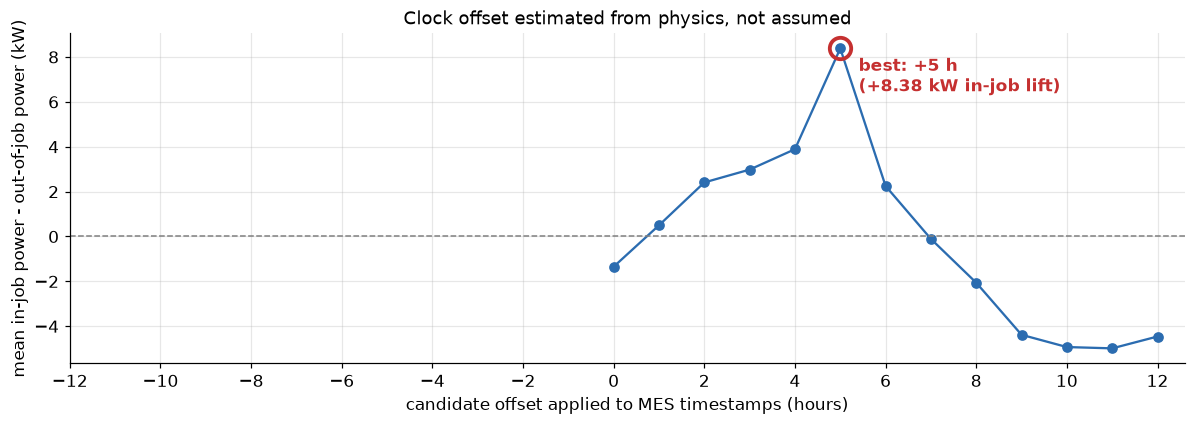

In [7]:
from src import preprocess
from src.config import load_config
from src import data_io, pipeline

cfg = load_config("/data/config.yaml")
power_c, rep_p = preprocess.clean_power(data_io.load_power(cfg.power_path), cfg)
vib_c, rep_v = preprocess.clean_vibration(data_io.load_vibration(cfg.vibration_path), cfg)
log_c, rep_l = preprocess.clean_production_log(data_io.load_production_log(cfg.production_log_path), cfg)

offsets = list(range(-12, 13))
scores = [preprocess._coverage_separation(power_c, log_c, h * 3600) for h in offsets]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(offsets, scores, "o-", color="#2b6cb0")
best_i = int(np.nanargmax(scores))
ax.plot(offsets[best_i], scores[best_i], "o", ms=14, mfc="none", mec="#c53030", mew=2.5)
ax.annotate(f"best: {offsets[best_i]:+d} h\n(+{scores[best_i]:.2f} kW in-job lift)",
            (offsets[best_i], scores[best_i]), textcoords="offset points", xytext=(12, -28),
            fontsize=11, color="#c53030", fontweight="bold")
ax.axhline(0, color="grey", lw=1, ls="--")
ax.set_xlabel("candidate offset applied to MES timestamps (hours)")
ax.set_ylabel("mean in-job power - out-of-job power (kW)")
ax.set_title("Clock offset estimated from physics, not assumed")
ax.set_xticks(offsets[::2])
plt.tight_layout()

align = preprocess.estimate_clock_offset(power_c, log_c, cfg)
print("applied offset      :", align["applied_offset_h"], "h")
print("per-machine estimate:", align["per_machine_best_offset_s"])
print("all machines agree  :", align["per_machine_agreement"])
print("in-job power lift   : %.2f kW  (vs %.2f kW with no offset)" % (
    align["best_separation_kw"], align["zero_offset_separation_kw"]))

A clean, unambiguous peak at **+5 h**, identical for all three machines independently
(so it is one plant-wide clock convention, not per-machine drift). The offset is
recomputed on every run, so a different shift in a different timezone needs no code change.

## 3. Sensor behaviour over the shift (facet grid, one panel per machine)

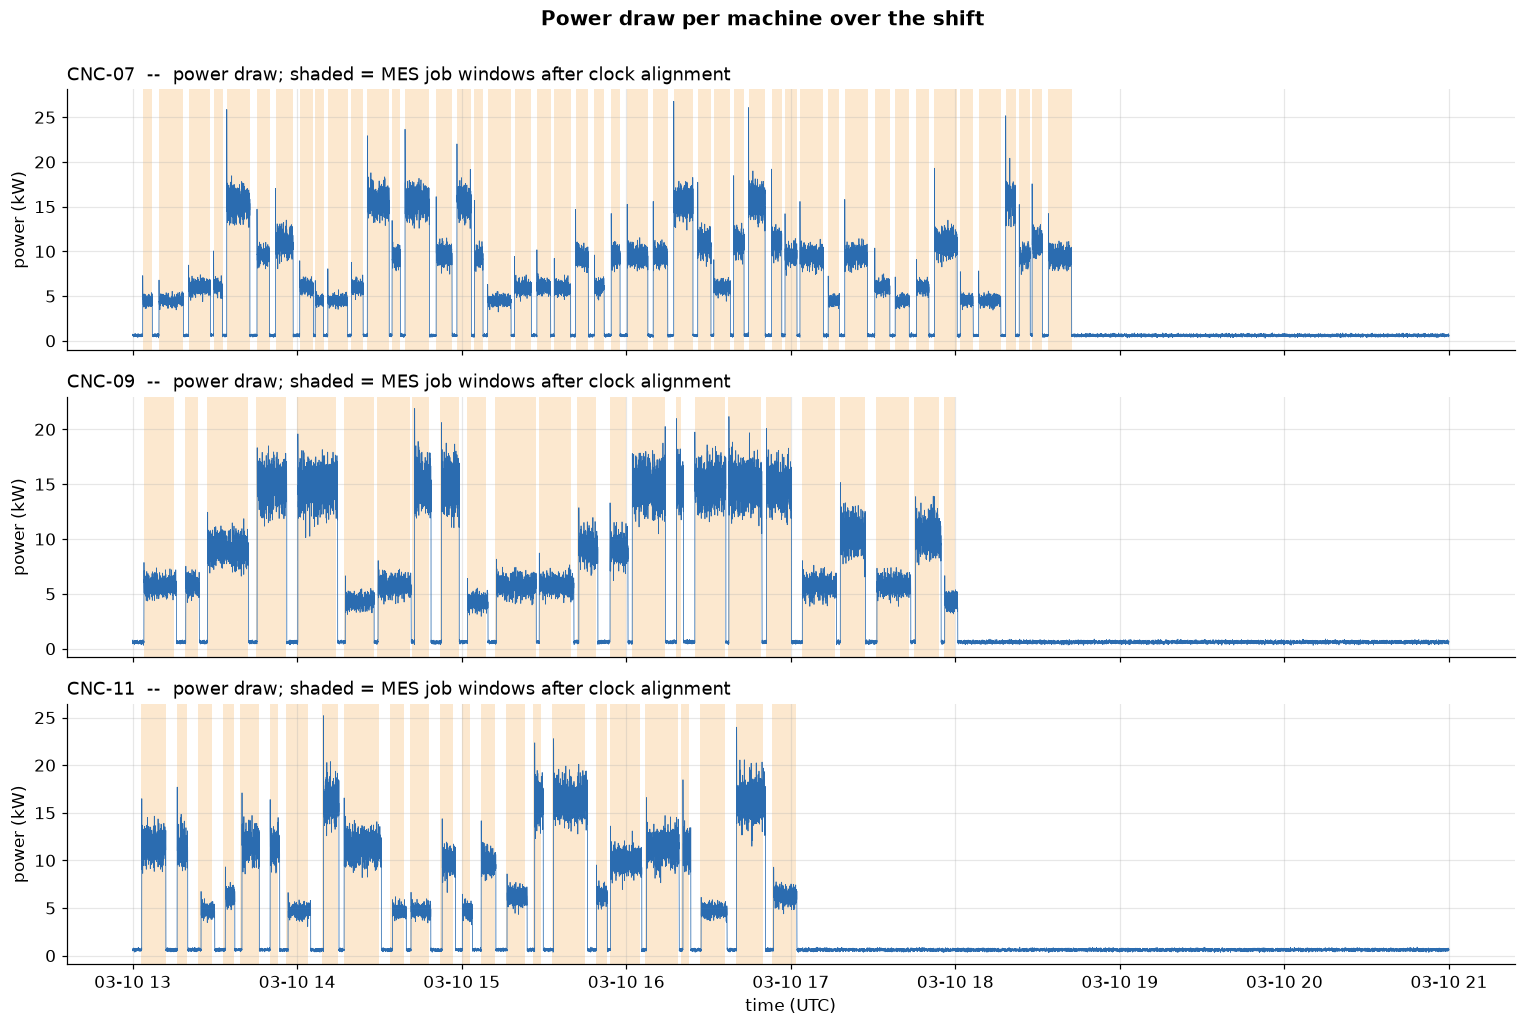

In [8]:
log_a = preprocess.apply_clock_offset(log_c, align["applied_offset_s"])
machines = sorted(power_c.machine_id.unique())

fig, axes = plt.subplots(len(machines), 1, figsize=(14, 3.1 * len(machines)), sharex=True)
axes = np.atleast_1d(axes)
for ax, m in zip(axes, machines):
    g = power_c[power_c.machine_id == m]
    ax.plot(g.timestamp, g.power_kw, lw=0.5, color="#2b6cb0")
    for r in log_a[log_a.machine_id == m].itertuples():
        ax.axvspan(r.start_time_aligned, r.end_time_aligned, color="#f6ad55", alpha=0.28, lw=0)
    ax.set_ylabel("power (kW)")
    ax.set_title(f"{m}  --  power draw; shaded = MES job windows after clock alignment", loc="left")
axes[-1].set_xlabel("time (UTC)")
fig.suptitle("Power draw per machine over the shift", y=1.0, fontsize=13, fontweight="bold")
plt.tight_layout()

The alignment is visually confirmed: every high-power block sits inside a shaded MES
window, and the gaps between blocks (setup/idle) are unshaded. Note the shift ends with a
long unshaded stretch -- the sensors keep logging after the last logged job.

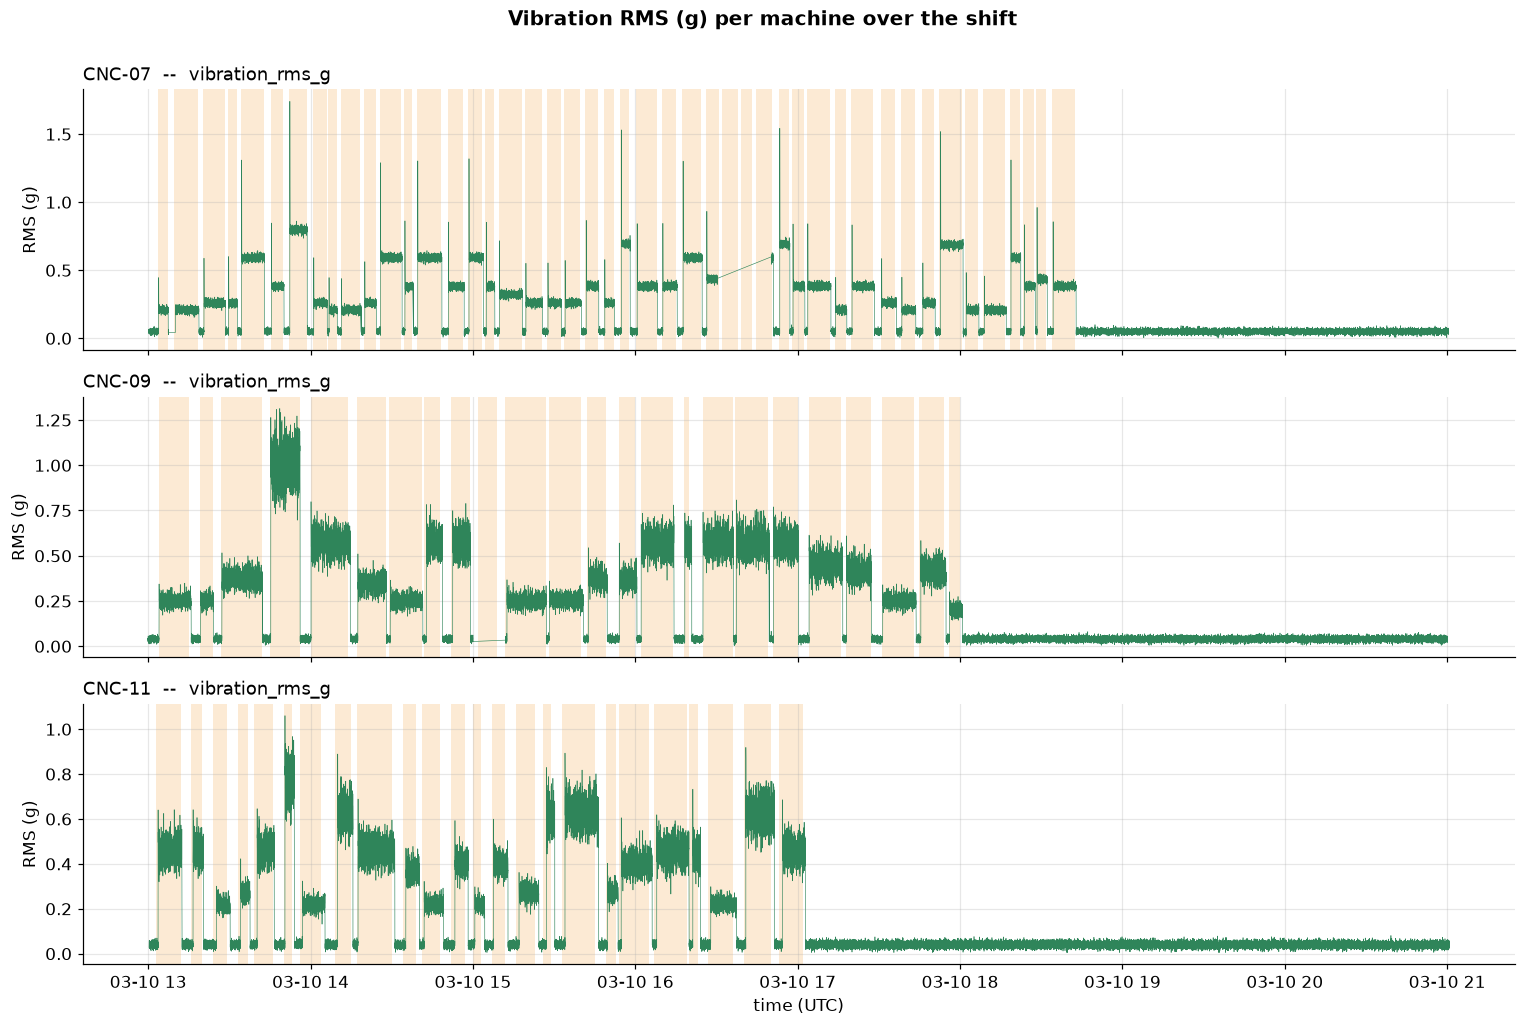

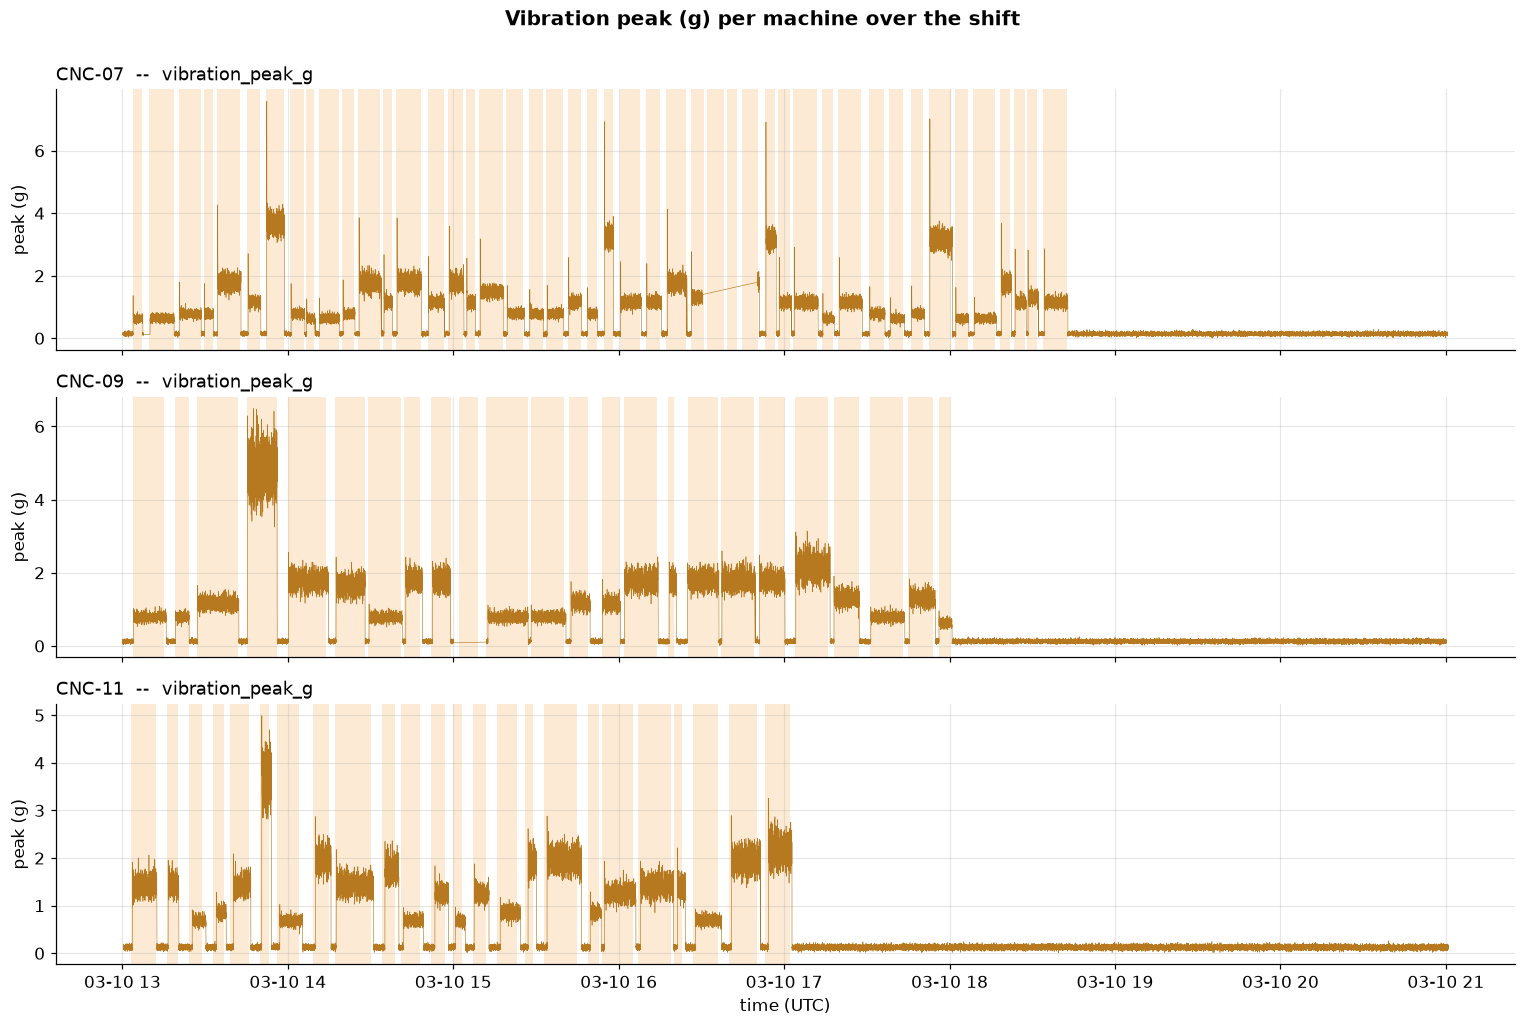

In [9]:
for col, unit, colour in [("vibration_rms_g", "RMS (g)", "#2f855a"), ("vibration_peak_g", "peak (g)", "#b7791f")]:
    fig, axes = plt.subplots(len(machines), 1, figsize=(14, 3.1 * len(machines)), sharex=True)
    axes = np.atleast_1d(axes)
    for ax, m in zip(axes, machines):
        g = vib_c[vib_c.machine_id == m]
        ax.plot(g.timestamp, g[col], lw=0.4, color=colour)
        for r in log_a[log_a.machine_id == m].itertuples():
            ax.axvspan(r.start_time_aligned, r.end_time_aligned, color="#f6ad55", alpha=0.25, lw=0)
        ax.set_ylabel(unit)
        ax.set_title(f"{m}  --  {col}", loc="left")
    axes[-1].set_xlabel("time (UTC)")
    fig.suptitle(f"Vibration {unit} per machine over the shift", y=1.0, fontsize=13, fontweight="bold")
    plt.tight_layout()

Vibration rises and falls with the job windows exactly as power does -- and a few blocks
stand out as visibly taller than their neighbours. Those are the candidates.

### 3.1 Sampling rates and sensor dropouts

In [10]:
for name, df in [("power", power_c), ("vibration", vib_c)]:
    d = df.sort_values(["machine_id", "timestamp"]).groupby("machine_id").timestamp.diff().dt.total_seconds()
    print(f"{name:10s} median interval {d.median():.2f}s  ->  {1/d.median():.1f} Hz")
    big = d[d > 5]
    print(f"{'':10s} gaps > 5 s: {len(big)}", ("| longest %.0f s (%.1f min)" % (big.max(), big.max()/60)) if len(big) else "")

vs = vib_c.sort_values(["machine_id", "timestamp"]).copy()
vs["gap"] = vs.groupby("machine_id").timestamp.diff().dt.total_seconds()
print("\nvibration dropouts:")
print(vs.loc[vs.gap > 5, ["machine_id", "timestamp", "gap"]].to_string(index=False))

power      median interval 1.00s  ->  1.0 Hz
           gaps > 5 s: 0 
vibration  median interval 0.50s  ->  2.0 Hz
           gaps > 5 s: 2 | longest 1201 s (20.0 min)

vibration dropouts:
machine_id               timestamp      gap
    CNC-07 2025-03-10 16:50:23.040 1201.461
    CNC-09 2025-03-10 15:12:00.169  720.288


Power is a clean 1 Hz with no gaps. Vibration is 2 Hz with **two dropouts** (20 min on one
machine, 12 min on another). Consequence: some jobs will have less vibration coverage than
others, so per-job verdicts must account for how many readings actually back them up rather
than treating every job as equally well observed.

## 4. Building the joined table

Two joins are needed:

1. **reading -> job**: interval containment on `machine_id` and aligned job start/end.
2. **vibration -> power**: the two sensors run at different rates (2 Hz vs 1 Hz) and are
   not co-sampled, so each vibration reading is matched to the nearest power reading within
   1 s (`merge_asof`). Resampling onto a common grid would blunt the peak metric, which we
   need at native resolution.

In [11]:
tables, diagnostics = pipeline.prepare_data(cfg, data_io.get_logger(False))
power_j, vib_j = tables["power"], tables["vibration"]
readings, cutting = tables["readings"], tables["cutting"]
idle_baseline = tables["idle_baseline"]
log_j = tables["production_log"]

print("power readings inside a job    : %6d / %6d (%.1f%%)" % (
    power_j.job_id.notna().sum(), len(power_j), 100 * power_j.job_id.notna().mean()))
print("vibration readings inside a job: %6d / %6d (%.1f%%)" % (
    vib_j.job_id.notna().sum(), len(vib_j), 100 * vib_j.job_id.notna().mean()))
print("jobs with at least one reading :", vib_j.job_id.nunique(), "of", len(log_j))
print()
print("idle baseline power per machine (min draw outside any job):")
print(idle_baseline.round(3).to_string())
print()
print("joined reading table:", readings.shape)
print(readings[["timestamp","machine_id","job_id","part_type","power_kw","net_power_kw",
                "vibration_rms_g","vibration_peak_g"]].head(5).to_string(index=False))

power readings inside a job    :  39350 /  86377 (45.6%)
vibration readings inside a job:  75689 / 168961 (44.8%)
jobs with at least one reading : 91 of 94

idle baseline power per machine (min draw outside any job):
machine_id
CNC-07    0.290
CNC-09    0.302
CNC-11    0.321

joined reading table: (75689, 17)
              timestamp machine_id  job_id  part_type  power_kw  net_power_kw  vibration_rms_g  vibration_peak_g
2025-03-10 13:03:00.192     CNC-11 JOB-201 ST-housing     0.531         0.210           0.0444            0.1362
2025-03-10 13:03:00.692     CNC-11 JOB-201 ST-housing     0.551         0.230           0.0350            0.1119
2025-03-10 13:03:01.193     CNC-11 JOB-201 ST-housing     0.551         0.230           0.0197            0.0616
2025-03-10 13:03:01.693     CNC-11 JOB-201 ST-housing     0.643         0.322           0.0411            0.1320
2025-03-10 13:03:02.194     CNC-11 JOB-201 ST-housing     0.643         0.322           0.0397            0.1240


Only ~45% of sensor readings fall inside a logged job -- the rest is setup/idle time. That
idle mass is not waste: it is exactly what we measure the **idle baseline** from, which the
brief requires us to subtract to get net cutting power.

## 5. Idle vs cutting: why the baseline subtraction matters

idle power per machine:
              count    min    50%     max
machine_id                               
CNC-07      13183.0  0.290  0.600   0.922
CNC-09      14911.0  0.302  0.605  20.254
CNC-11      18933.0  0.321  0.603  19.685


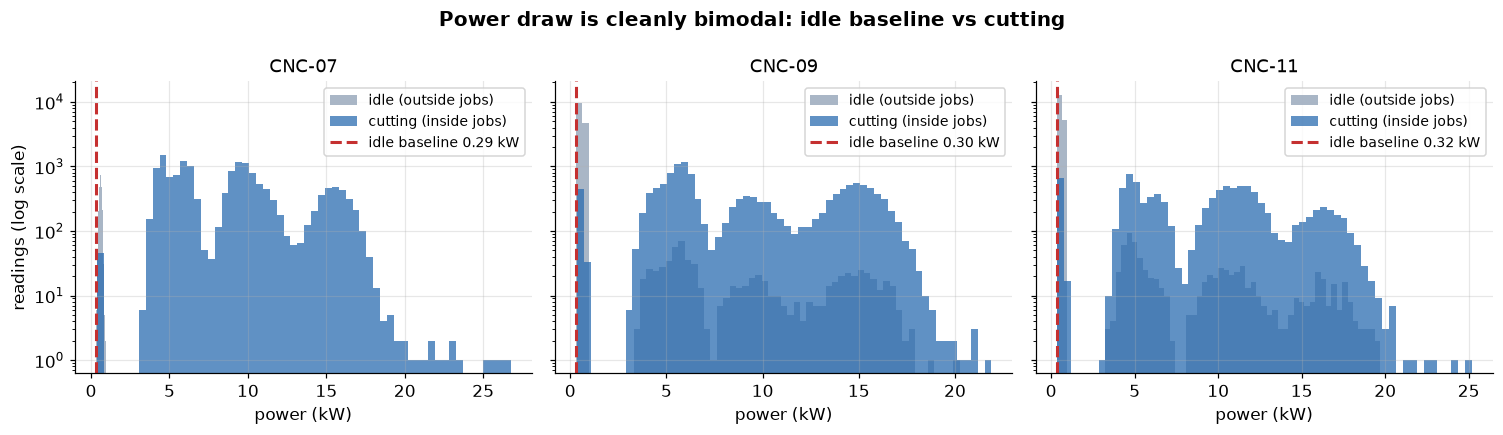

In [12]:
idle_pw = power_j[power_j.job_id.isna()]
job_pw = power_j[power_j.job_id.notna()]

fig, axes = plt.subplots(1, len(machines), figsize=(4.6 * len(machines), 4.0), sharey=True)
axes = np.atleast_1d(axes)
for ax, m in zip(axes, machines):
    ax.hist(idle_pw.loc[idle_pw.machine_id == m, "power_kw"], bins=60, color="#a0aec0",
            label="idle (outside jobs)", alpha=0.9)
    ax.hist(job_pw.loc[job_pw.machine_id == m, "power_kw"], bins=60, color="#2b6cb0",
            label="cutting (inside jobs)", alpha=0.75)
    ax.axvline(idle_baseline[m], color="#c53030", lw=2, ls="--",
               label=f"idle baseline {idle_baseline[m]:.2f} kW")
    ax.set_yscale("log")
    ax.set_xlabel("power (kW)")
    ax.set_title(m)
    ax.legend(fontsize=9)
axes[0].set_ylabel("readings (log scale)")
fig.suptitle("Power draw is cleanly bimodal: idle baseline vs cutting", fontsize=13, fontweight="bold")
plt.tight_layout()

print("idle power per machine:")
print(idle_pw.groupby("machine_id").power_kw.describe()[["count","min","50%","max"]].round(3).to_string())

The idle mode is tight (~0.3 kW) and well separated from cutting, so
`mean_power_kw = mean(power in job) - min(idle power for that machine)` is a stable
quantity. All three machines idle at almost the same draw, but the baseline is computed
per machine so a fleet with mixed hardware still works.

Note a job window can briefly contain near-idle moments (repositioning / air cuts). Those
readings carry no cutting work, so a vibration-per-power ratio computed there is
meaningless; we exclude readings below a small cutting-power floor from the *model* while
still counting them in the reported job means.

## 6. The core relationship: vibration vs power

This is the heart of the problem. A healthy tool's vibration should scale predictably with
power; a worn tool should sit above that line.

correlation of net power with vibration RMS:
  overall:            0.730
  within AL-bracket: -0.128   (power range 3.6-4.9 kW)
  within AL-panel:   0.003   (power range 4.7-6.6 kW)
  within ST-gear:    -0.066   (power range 7.9-10.5 kW)
  within ST-housing: -0.050   (power range 9.1-12.6 kW)
  within TI-fitting: -0.065   (power range 12.8-17.2 kW)


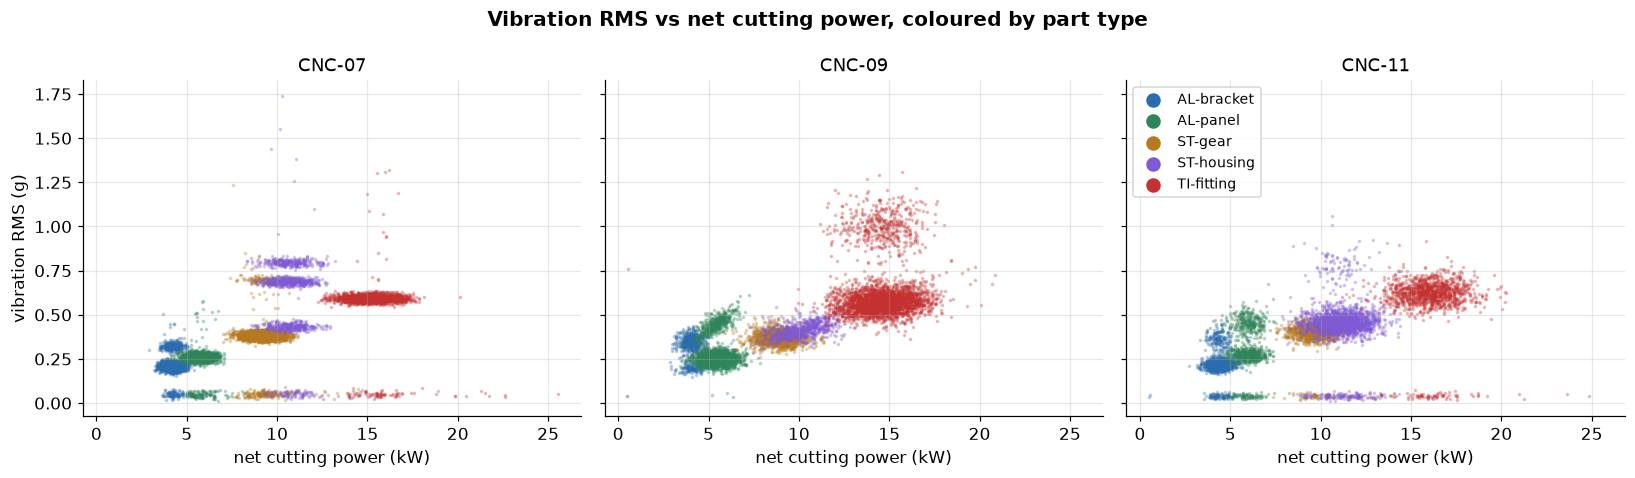

In [13]:
parts = sorted(cutting.part_type.dropna().unique())
colours = dict(zip(parts, ["#2b6cb0", "#2f855a", "#b7791f", "#805ad5", "#c53030"]))

fig, axes = plt.subplots(1, len(machines), figsize=(5.0 * len(machines), 4.4), sharex=True, sharey=True)
axes = np.atleast_1d(axes)
samp = cutting.sample(min(25000, len(cutting)), random_state=1)
for ax, m in zip(axes, machines):
    g = samp[samp.machine_id == m]
    for pt in parts:
        gg = g[g.part_type == pt]
        ax.scatter(gg.net_power_kw, gg.vibration_rms_g, s=2, alpha=0.25, color=colours[pt], label=pt)
    ax.set_xlabel("net cutting power (kW)")
    ax.set_title(m)
axes[0].set_ylabel("vibration RMS (g)")
leg = axes[-1].legend(markerscale=6, fontsize=9, loc="upper left")
for lh in leg.legend_handles:
    lh.set_alpha(1)
fig.suptitle("Vibration RMS vs net cutting power, coloured by part type", fontsize=13, fontweight="bold")
plt.tight_layout()

print("correlation of net power with vibration RMS:")
print("  overall:            %.3f" % cutting.net_power_kw.corr(cutting.vibration_rms_g))
for pt in parts:
    g = cutting[cutting.part_type == pt]
    print("  within %-11s %.3f   (power range %.1f-%.1f kW)" % (
        pt + ":", g.net_power_kw.corr(g.vibration_rms_g), g.net_power_kw.quantile(.05), g.net_power_kw.quantile(.95)))

**Critical observation.** Overall the correlation is very strong, but *within* a part type
it collapses to ~0. Two things follow:

1. Part type largely determines the operating point (an AL bracket cuts at ~4 kW, a TI
   fitting at ~15 kW), so most of the overall correlation is between-material variation.
2. Within a material, instantaneous power and instantaneous vibration fluctuate
   independently around a stable *mean ratio* -- the two sensors sample different physical
   quantities at different times. So a per-reading correlation is not the signal; the
   **ratio level** is.

The scatter also shows distinct parallel bands within each colour -- some jobs sit on a
visibly steeper ray from the origin. That is the wear signature.

### 6.1 The relationship is multiplicative, not additive

spread of vibration by power sextile:
               power  sd_rms  sd_log_rms
net_power_kw                            
0              4.238  0.0743      0.4281
1              5.414  0.0794      0.3918
2              7.834  0.1107      0.5010
3              9.771  0.1418      0.5339
4             12.521  0.1716      0.5566
5             15.596  0.1542      0.5192

sd(rms) grows 2.3x across the power range; sd(log rms) grows only 1.4x


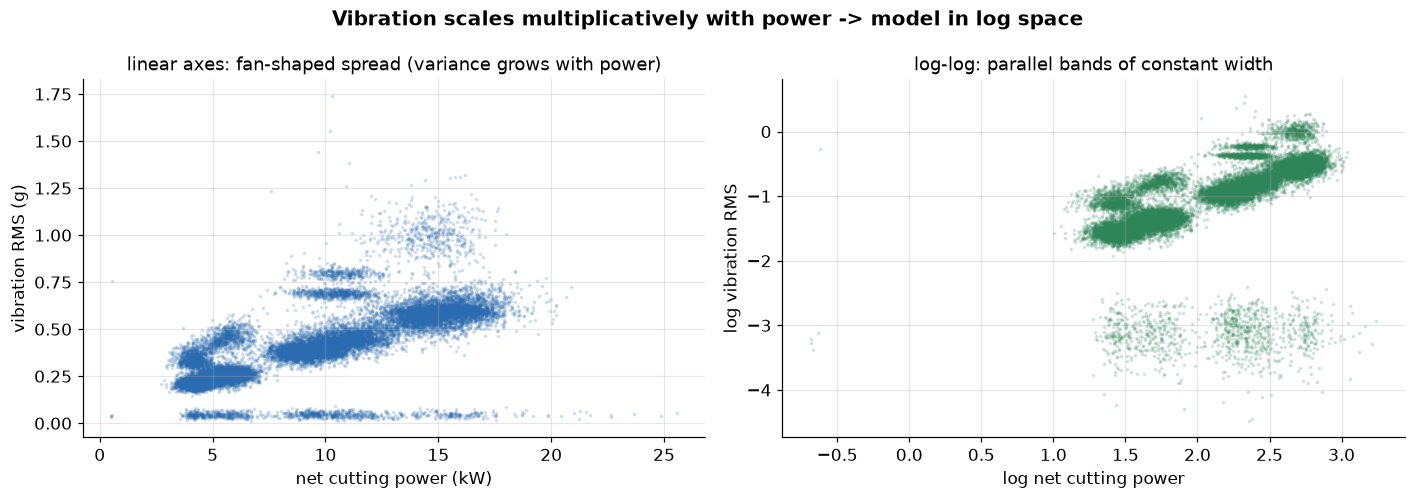

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ax = axes[0]
ax.scatter(samp.net_power_kw, samp.vibration_rms_g, s=2, alpha=0.15, color="#2b6cb0")
ax.set_xlabel("net cutting power (kW)"); ax.set_ylabel("vibration RMS (g)")
ax.set_title("linear axes: fan-shaped spread (variance grows with power)")

ax = axes[1]
ax.scatter(np.log(samp.net_power_kw), np.log(samp.vibration_rms_g), s=2, alpha=0.15, color="#2f855a")
ax.set_xlabel("log net cutting power"); ax.set_ylabel("log vibration RMS")
ax.set_title("log-log: parallel bands of constant width")
fig.suptitle("Vibration scales multiplicatively with power -> model in log space",
             fontsize=13, fontweight="bold")
plt.tight_layout()

q = pd.qcut(cutting.net_power_kw, 6, labels=False, duplicates="drop")
sd = cutting.groupby(q).agg(power=("net_power_kw", "median"),
                            sd_rms=("vibration_rms_g", "std"),
                            sd_log_rms=("log_vibration_rms_g", "std"))
print("spread of vibration by power sextile:")
print(sd.round(4).to_string())
print("\nsd(rms) grows %.1fx across the power range; sd(log rms) grows only %.1fx" % (
    sd.sd_rms.max() / sd.sd_rms.min(), sd.sd_log_rms.max() / sd.sd_log_rms.min()))

On linear axes the residual spread grows with power (heteroscedastic); in logs it is
nearly constant. This matters directly for the 6-sigma rule: with an additive model a
single sigma cannot serve both a 4 kW aluminium cut and a 15 kW titanium cut, so the
threshold would be simultaneously too tight for the former and too loose for the latter.
**We therefore model `log(vibration RMS)` against `log(net power)`**, which makes the
residual a scale-free "% excess vibration".

### 6.2 Vibration-per-kW isolates the wear signal

median g per net kW by machine x part type:
part_type   AL-bracket  AL-panel  ST-gear  ST-housing  TI-fitting
machine_id                                                       
CNC-07          0.0502    0.0452   0.0415      0.0627      0.0388
CNC-09          0.0805    0.0472   0.0418      0.0409      0.0397
CNC-11          0.0500    0.0497   0.0411      0.0406      0.0387


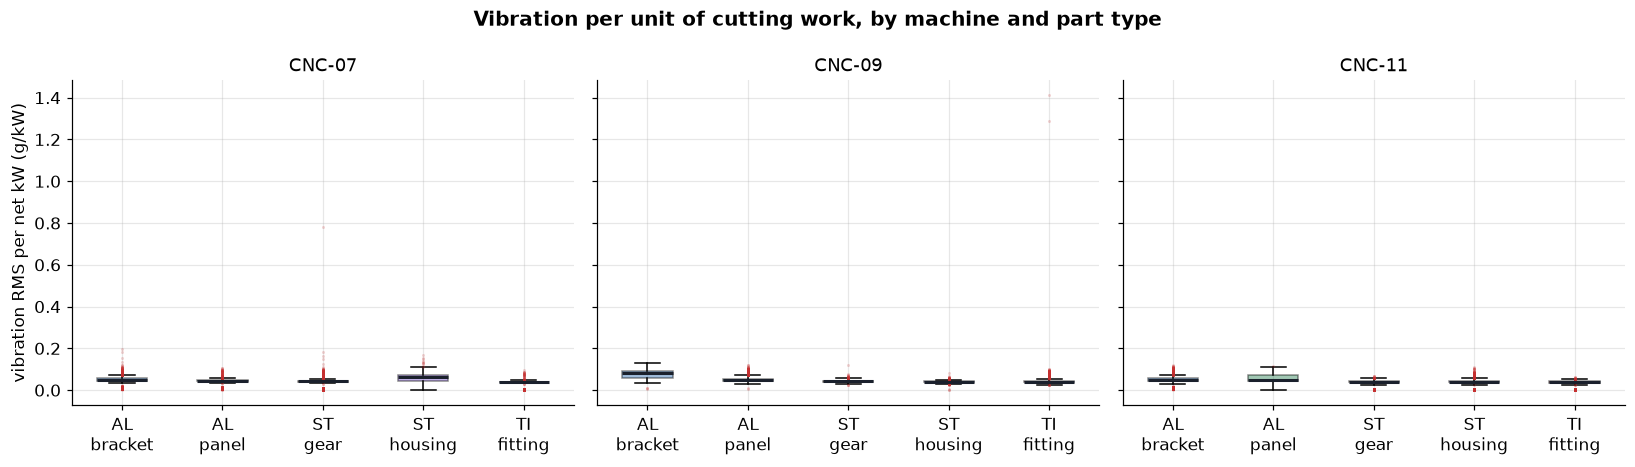

In [15]:
cutting = cutting.assign(ratio=cutting.vibration_rms_g / cutting.net_power_kw)

fig, axes = plt.subplots(1, len(machines), figsize=(5.0 * len(machines), 4.3), sharey=True)
axes = np.atleast_1d(axes)
for ax, m in zip(axes, machines):
    g = cutting[cutting.machine_id == m]
    data = [g.loc[g.part_type == pt, "ratio"].values for pt in parts]
    bp = ax.boxplot(data, tick_labels=[p.replace("-", "\n") for p in parts], showfliers=True,
                    flierprops=dict(marker=".", ms=2, alpha=0.2, mec="#c53030"),
                    medianprops=dict(color="#1a202c", lw=2), patch_artist=True)
    for patch, pt in zip(bp["boxes"], parts):
        patch.set_facecolor(colours[pt]); patch.set_alpha(0.45)
    ax.set_title(m)
axes[0].set_ylabel("vibration RMS per net kW (g/kW)")
fig.suptitle("Vibration per unit of cutting work, by machine and part type",
             fontsize=13, fontweight="bold")
plt.tight_layout()

print("median g per net kW by machine x part type:")
print(cutting.pivot_table(index="machine_id", columns="part_type", values="ratio", aggfunc="median").round(4).to_string())

The ratio is tight and remarkably consistent across machines for the same material
(~0.049 g/kW for AL brackets down to ~0.039 for TI fittings), with long upper tails. Two
cells look inflated -- and that turns out to be *contamination of the cohort by worn jobs*
rather than a machine effect, which is why the baseline must be estimated robustly (see 6.3).

Material matters, machine barely does. So `part_type` is an essential control; `machine_id`
is worth keeping but should not be allowed to absorb the signal.

### 6.3 Per-job view: the wear signal is bimodal

healthy bulk : 80 jobs, relative ratio 0.967-1.016 (sd 0.0094)
elevated     : 11 jobs, relative ratio 1.557-1.848

GAP between the two groups: 1.016 -> 1.557 (nothing in between)

elevated jobs:
 job_id machine_id  part_type    n  ratio   rel  crest  mean_power  peak_vib
JOB-007     CNC-07 ST-housing  768  0.074 1.848  4.581      10.719     7.578
JOB-120     CNC-09   AL-panel 1414  0.083 1.828  4.789       5.423     3.140
JOB-024     CNC-07    ST-gear  386  0.074 1.788  4.583       9.300     6.930
JOB-106     CNC-09 AL-bracket 1256  0.086 1.755  4.764       4.042     2.291
JOB-104     CNC-09 TI-fitting 1275  0.068 1.747  4.785      14.652     6.489
JOB-206     CNC-11 ST-housing  345  0.068 1.683  4.747      11.059     4.990
JOB-210     CNC-11 AL-bracket  512  0.082 1.673  4.745       4.364     2.364
JOB-224     CNC-11   AL-panel  990  0.076 1.668  4.761       5.971     3.255
JOB-032     CNC-07 ST-housing  445  0.064 1.594  4.546      10.783     6.916
JOB-040     CNC-07 ST-housing  991 

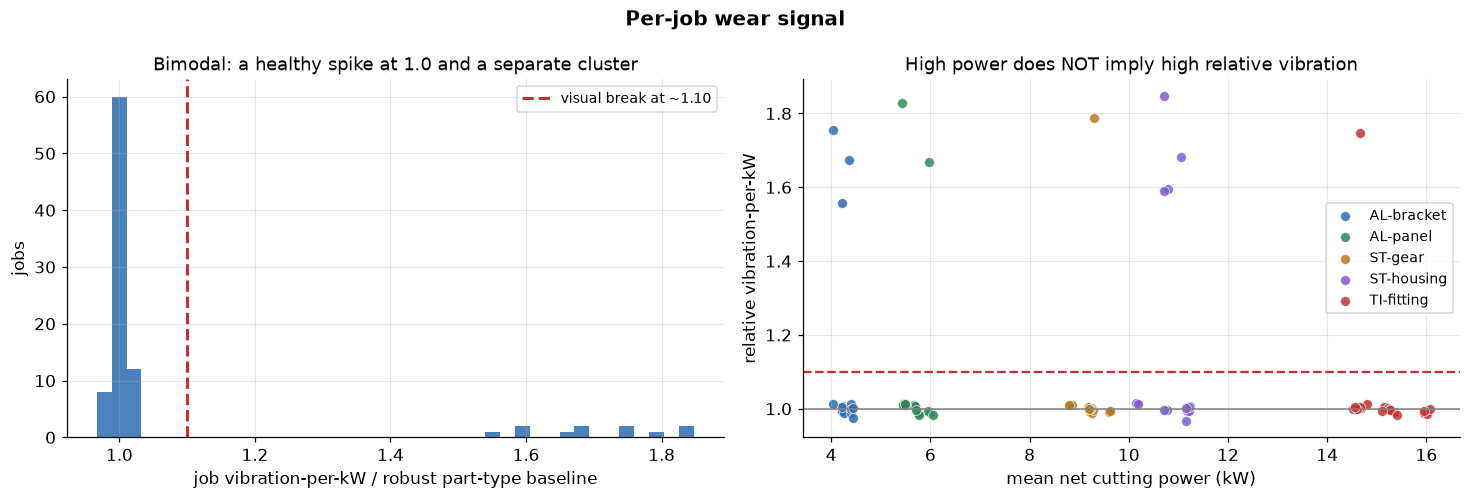

In [16]:
job_ratio = cutting.groupby(["job_id", "machine_id", "part_type"], observed=True).agg(
    n=("ratio", "size"), ratio=("ratio", "median"), crest=("peak_to_rms", "median"),
    mean_power=("net_power_kw", "mean"), peak_vib=("vibration_peak_g", "max")).reset_index()

# Robust part-type baseline: trim the upper tail, recompute, iterate. A plain median is
# contaminated where several jobs in a small cohort are worn.
base = job_ratio.groupby("part_type").ratio.median()
for _ in range(10):
    rel = job_ratio.ratio / job_ratio.part_type.map(base)
    new = job_ratio[rel < 1.10].groupby("part_type").ratio.median().reindex(base.index).fillna(base)
    if np.allclose(new.values, base.values):
        break
    base = new
job_ratio["rel"] = job_ratio.ratio / job_ratio.part_type.map(base)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
ax = axes[0]
ax.hist(job_ratio.rel, bins=40, color="#2b6cb0", alpha=0.85)
ax.axvline(1.10, color="#c53030", ls="--", lw=2, label="visual break at ~1.10")
ax.set_xlabel("job vibration-per-kW / robust part-type baseline")
ax.set_ylabel("jobs"); ax.set_title("Bimodal: a healthy spike at 1.0 and a separate cluster")
ax.legend(fontsize=9)

ax = axes[1]
for pt in parts:
    g = job_ratio[job_ratio.part_type == pt]
    ax.scatter(g.mean_power, g.rel, s=42, alpha=0.85, color=colours[pt], label=pt, edgecolor="white", lw=0.5)
ax.axhline(1.0, color="grey", lw=1)
ax.axhline(1.10, color="#c53030", ls="--", lw=1.5)
ax.set_xlabel("mean net cutting power (kW)"); ax.set_ylabel("relative vibration-per-kW")
ax.set_title("High power does NOT imply high relative vibration")
ax.legend(fontsize=9)
fig.suptitle("Per-job wear signal", fontsize=13, fontweight="bold")
plt.tight_layout()

healthy = job_ratio[job_ratio.rel < 1.10]
sus = job_ratio[job_ratio.rel >= 1.10].sort_values("rel", ascending=False)
print("healthy bulk : %d jobs, relative ratio %.3f-%.3f (sd %.4f)" % (
    len(healthy), healthy.rel.min(), healthy.rel.max(), healthy.rel.std()))
print("elevated     : %d jobs, relative ratio %.3f-%.3f" % (len(sus), sus.rel.min(), sus.rel.max()))
print("\nGAP between the two groups: %.3f -> %.3f (nothing in between)" % (healthy.rel.max(), sus.rel.min()))
print("\nelevated jobs:")
print(sus[["job_id","machine_id","part_type","n","ratio","rel","crest","mean_power","peak_vib"]].round(3).to_string(index=False))

This is the key exploratory result. The distribution is **strongly bimodal**: 80 jobs sit
within +-2% of their material's baseline, and 11 jobs sit 56-85% above it, with an empty
gap between 1.016 and 1.557. There is nothing borderline in this shift.

The right-hand panel makes the point the brief warns about: the elevated jobs span the
whole power range (a 4 kW aluminium bracket and a 15 kW titanium fitting are both in the
set), so raw power or raw vibration alone would rank the wrong jobs.

### 6.4 Independent confirmation: crest factor

The ratio and the model that follows both use the same two channels. An *independent*
signature is the crest factor `peak / RMS`: chatter is impulsive, so a chipped tool should
raise peaks more than it raises RMS. Nothing in our detector uses this to decide, which
makes it a genuine validation check.

crest factor  ratio-normal jobs: 2.950 - 3.137
crest factor  ratio-elevated   : 4.546 - 4.789
=> perfectly separable, and it agrees with the ratio split on all 91 jobs


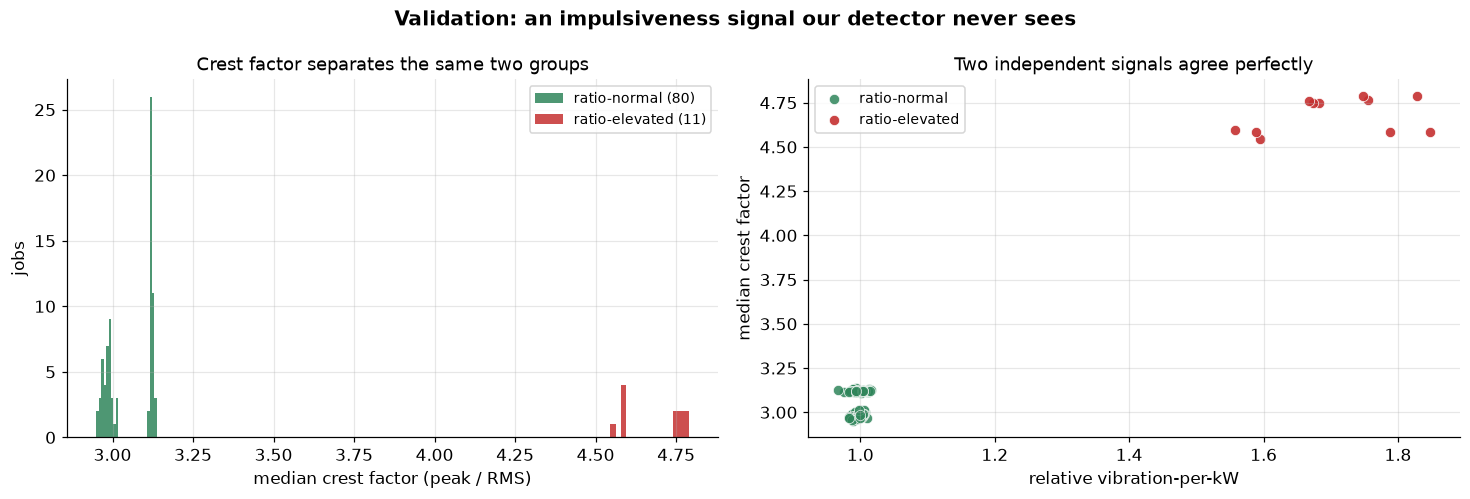

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
ax = axes[0]
ax.hist(healthy.crest, bins=25, color="#2f855a", alpha=0.85, label=f"ratio-normal ({len(healthy)})")
ax.hist(sus.crest, bins=15, color="#c53030", alpha=0.85, label=f"ratio-elevated ({len(sus)})")
ax.set_xlabel("median crest factor (peak / RMS)"); ax.set_ylabel("jobs")
ax.set_title("Crest factor separates the same two groups"); ax.legend(fontsize=9)

ax = axes[1]
ax.scatter(healthy.rel, healthy.crest, s=45, color="#2f855a", alpha=0.85, label="ratio-normal", edgecolor="white", lw=0.5)
ax.scatter(sus.rel, sus.crest, s=45, color="#c53030", alpha=0.9, label="ratio-elevated", edgecolor="white", lw=0.5)
ax.set_xlabel("relative vibration-per-kW"); ax.set_ylabel("median crest factor")
ax.set_title("Two independent signals agree perfectly"); ax.legend(fontsize=9)
fig.suptitle("Validation: an impulsiveness signal our detector never sees",
             fontsize=13, fontweight="bold")
plt.tight_layout()

print("crest factor  ratio-normal jobs: %.3f - %.3f" % (healthy.crest.min(), healthy.crest.max()))
print("crest factor  ratio-elevated   : %.3f - %.3f" % (sus.crest.min(), sus.crest.max()))
print("=> perfectly separable, and it agrees with the ratio split on all %d jobs" % len(job_ratio))

The crest factor separates the two groups with a wide margin (<=3.14 vs >=4.55) and agrees
with the ratio-based split on every single job. Two physically distinct symptoms --
more vibration per unit of work, and more impulsive vibration -- point at the same 11 jobs.
That is strong evidence the signal is real tool wear and not an artefact of one metric.

### 6.5 Is the elevation sustained, or a transient?

per-job sequence on each machine (S = elevated), in job start order:
  CNC-07: ......S..........S.....S.....S.......S......
  CNC-09: ...S.S............S....
  CNC-11: .....S...S.............S

elevated jobs per machine x part cell (elevated / total):
part_type  AL-bracket AL-panel ST-gear ST-housing TI-fitting
machine_id                                                  
CNC-07          1 / 9   0 / 10  1 / 13      3 / 5      0 / 7
CNC-09          1 / 2    1 / 7   0 / 3      0 / 2      1 / 9
CNC-11          1 / 6    1 / 4   0 / 3      1 / 7      0 / 4


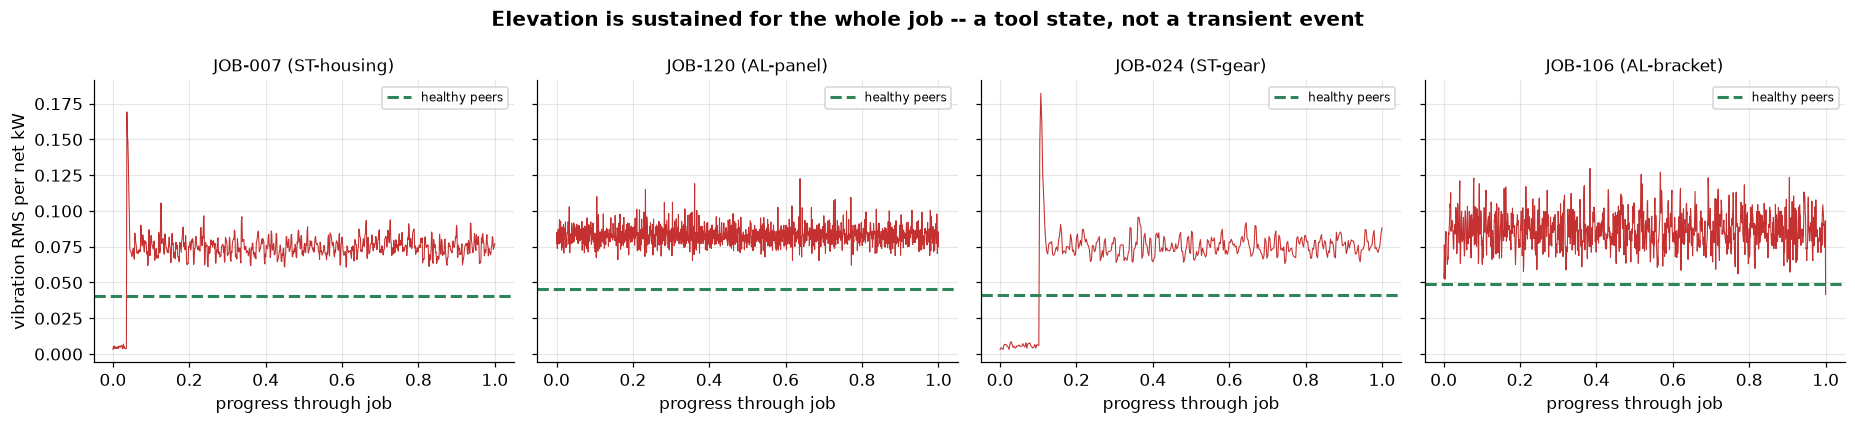

In [18]:
top = sus.job_id.head(4).tolist()
fig, axes = plt.subplots(1, 4, figsize=(17, 3.9), sharey=True)
for ax, jid in zip(axes, top):
    g = cutting[cutting.job_id == jid].sort_values("timestamp")
    pt = g.part_type.iloc[0]
    peer = cutting[(cutting.part_type == pt) & (~cutting.job_id.isin(sus.job_id))]
    ax.plot(np.arange(len(g)) / max(len(g) - 1, 1), g.ratio, lw=0.7, color="#c53030")
    ax.axhline(peer.ratio.median(), color="#2f855a", lw=2, ls="--", label="healthy peers")
    ax.set_title(f"{jid} ({pt})", fontsize=11)
    ax.set_xlabel("progress through job")
    ax.legend(fontsize=8)
axes[0].set_ylabel("vibration RMS per net kW")
fig.suptitle("Elevation is sustained for the whole job -- a tool state, not a transient event",
             fontsize=13, fontweight="bold")
plt.tight_layout()

print("per-job sequence on each machine (S = elevated), in job start order:")
seq = job_ratio.merge(log_j[["job_id","start_time_aligned"]], on="job_id").sort_values(["machine_id","start_time_aligned"])
for m, g in seq.groupby("machine_id"):
    print(f"  {m}: " + "".join("S" if r else "." for r in (g.rel >= 1.10)))
print("\nelevated jobs per machine x part cell (elevated / total):")
el = pd.crosstab(seq.machine_id, seq.part_type, values=(seq.rel >= 1.10).astype(int), aggfunc="sum").fillna(0).astype(int)
tt = pd.crosstab(seq.machine_id, seq.part_type)
print((el.astype(str) + " / " + tt.astype(str)).to_string())

The elevation is flat across the entire job, not a spike, so it reflects the **state of the
tool mounted for that job** rather than a momentary disturbance. The elevated jobs are
scattered across machines and materials and are isolated in time (no runs of consecutive
affected jobs), consistent with individual worn tools rather than a bad machine or a bad
batch of material.

**Important modelling consequence:** because 3 of the 5 ST-housing jobs on one machine are
elevated, a `machine x part_type` cohort mean would be dragged up by the wear itself and
the signal would partly vanish. The baseline must therefore be estimated with a **robust**
regressor, and we must not include the full `machine x part` interaction.

## 7. Feature engineering (implemented in `src/features.py`)

| Feature | Definition | Why |
|---|---|---|
| `net_power_kw` | `power_kw - machine idle minimum` | isolates the power actually spent cutting; per the brief |
| `log_net_power_kw` | `log(net_power_kw)` | linearises the multiplicative relationship (6.1) |
| `log_vibration_rms_g` | `log(vibration_rms_g)` | homoscedastic target, so one sigma serves all materials |
| `vib_per_kw`, `log_vib_per_kw` | `rms / net_power_kw` | the direct physical wear ratio (6.2) |
| `peak_to_rms` | `vibration_peak_g / vibration_rms_g` | crest factor -- impulsiveness of chatter (6.4) |
| `part_type` (one-hot) | material + part | sets the operating point; the dominant control (6.2) |
| `machine_id` (one-hot) | machine | small but real per-machine differences |
| `quantity` | batch size from the MES | weak context; included as the brief asks |
| `log_power x part_type`, `log_power x machine_id` | interactions | lets each material/machine have its own slope, so a heavy TI cut is judged against other heavy TI cuts |

Excluded on purpose: the full `machine x part_type` interaction (would absorb the wear, 6.5)
and `operator` (no physical mechanism; with 9 operators over 94 jobs it invites spurious
attribution).

## 8. Recommended model architectures for `02_anomaly_models.ipynb`

The EDA supports a **two-stage detector**: a physics-informed regression baseline plus an
independent unsupervised check, with a reading flagged only when both agree.

**Stage 1 -- primary (residual from the healthy vibration/power law).** Predict
`log(vibration RMS)` from `log(net power)` + machine + part + interactions, then flag
readings whose residual exceeds 6 robust sigma above the fit. Candidates:

1. **Ridge** -- L2 least squares. Fast, but every worn reading pulls the baseline toward
   itself, and it inflates the residual sigma it is measured against. Expect the weakest
   separation; useful as the honest baseline.
2. **Huber** -- squared loss near the centre, linear in the tails. Should downweight the
   ~13% contaminated readings while still using all the data.
3. **RANSAC / robust consensus** -- fits on a maximal inlier consensus set, so the baseline
   is estimated almost purely from healthy readings. Expect the cleanest margin.

Sigma must be estimated robustly (MAD, not the sample standard deviation): with 13% of
readings contaminated, an ordinary sigma is inflated by the very anomalies it should be
detecting, and 6-sigma would then flag almost nothing.

**Stage 2 -- secondary (unsupervised multivariate outlier).** On
`[log_net_power_kw, log_vib_per_kw, peak_to_rms]`, which adds the crest-factor axis the
regression never sees. Candidates:

4. **Isolation Forest** -- axis-aligned random partitioning; cheap, scales well.
5. **Mahalanobis distance** (robust/trimmed covariance) -- the healthy cloud is a compact
   ellipsoid in log space, which is exactly the assumption this makes.
6. **Local Outlier Factor** -- density-based; catches local structure, but must be fitted
   against a reference subsample at this data volume.

Because the two stages are combined with a logical AND, the secondary detector's
`contamination` prior must be set generously (the EDA says ~12% of *readings* are affected).
A tight prior there would silently veto true positives.

**Job-level verdict.** Reading-level flags are aggregated per job: `wear_score` is a high
quantile of the primary sigma, and a job is flagged only if enough of its readings fire
both stages. Jobs with too few cutting readings get **no verdict** rather than a guess --
the two sensor dropouts (3.1) make that a real case.

## 9. Summary of EDA findings

1. **The two clocks disagree by 5 h** (sensors UTC, MES local). This is the single defect
   that would silently break the whole analysis; it is estimated from the data.
2. **Data defects are few and all repairable**: 7 bad power readings, 13 duplicate rows,
   3 transposed job intervals, 3 missing quantities.
3. **Power is cleanly bimodal** (idle ~0.3 kW vs cutting), so the idle-baseline subtraction
   is well defined.
4. **Vibration scales multiplicatively with power**, so the model belongs in log space.
5. **Part type sets the operating point; machine barely matters.** Controlling for material
   is essential to avoid flagging heavy titanium cuts.
6. **The wear signal is bimodal and stark**: 11 of 91 assessable jobs sit 56-85% above their
   material baseline, with an empty gap separating them from the healthy bulk.
7. **An independent crest-factor signal agrees on all 11 jobs**, which is our main
   confidence check.
8. **Two vibration dropouts** mean per-job coverage is uneven; verdicts must be
   coverage-aware.